# Part 3 — The product: forecasting the rest of a season

Parts 1 and 2 both describe a season that has **already happened** — how faithful the surface is, how sure we are about a completed line, what a hitter's true talent was. This part asks the question a team actually has in May: stand at a hitter's **first *k* plate appearances** and forecast his **final full-season xwOBA** — not a point estimate alone, but a calibrated range that tightens as the games play out.

The model in one line:

> θ_{i,t} = μ_t + η_i + u_{i,t}

A hitter's current-season talent θ is a season league environment μ_t, plus a **career random intercept η_i** — his own norm across his completed prior seasons — plus an iid season wobble u. That career intercept is the whole new lever over Part 2, which estimated each season in *isolation*; this finally lets a hitter's own past inform his present. It stays closed-form Gaussian (a small per-player Kalman solve), ~20 s to sweep thousands of forecasts with no MCMC, reusing Level 2's `bootstrap_S` and the forward-bootstrap idea from Part 2's player bands.

Two questions get answered here: does the forecast beat the standard baselines (yes — including Marcel, with a CI that excludes zero), and does spray — the surface win from Part 1 — sharpen it (no — pull tendency is forecast-redundant). Everything comes from `results/talent3/`.

In [1]:
# --- setup: locate the repo and import the shared notebook helpers (run this first) ---
import sys
from pathlib import Path

_root = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "config.yaml").exists()), Path.cwd())
sys.path.insert(0, str(_root / "notebooks"))
from nb_helpers import ROOT, RESULTS, jload, show_fig

import polars as pl
from IPython.display import Markdown, display

print("repo root:", ROOT)
print("results:  ", RESULTS, "(exists)" if RESULTS.exists() else "(MISSING)")

repo root: /Users/jweinga/Documents/python/xwobart
results:   /Users/jweinga/Documents/python/xwobart/results (exists)


In [2]:
m  = jload("talent3/metrics.json")
pc = jload("talent3/precheck_pull.json")     # rung-b spray pre-check
pr, pb, gates = m["pooled_rmse"], m["paired_bootstrap"], m["gates"]

print("loaded: talent3/metrics.json, talent3/precheck_pull.json")

loaded: talent3/metrics.json, talent3/precheck_pull.json


## The setup, and the scale

The final line is a known-weight blend of what already happened and what hasn't — `r_final = (1−w)·r_obs + w·r_rest`, where `w` is the share of the season still to play. What's in the books is locked; only the rest-of-season rate `r_rest` has to be forecast, and the range comes from forward-bootstrapping the player's own contact. Fitting is **leave-one-season-out** — to forecast a season, the hierarchy's variances are fit on the *other* seasons only — and every forecast passes a causal leakage guard (`assert_causal`) that refuses any conditioning PA post-dating its cutpoint.

**What to look for:** the leakage guard clean on every forecast, and the eligible count thinning as *k* grows — a benched hitter has no rest-of-season left to forecast.

In [3]:
lk = m["leakage"]
display(pl.DataFrame([{
    "forecasts": lk["n_forecasts"], "(batter, season) pairs": m["n_pairs"],
    "distinct batters": m["n_batters"], "conditioning rows checked": lk["n_conditioning_rows"],
    "assert_causal": lk["assert_causal"], "seed": lk["seed"],
}]))
pl.DataFrame([{"k (PAs seen)": int(k), "eligible forecasts": m["eligible_counts_by_k"][k]}
              for k in ("50", "100", "150", "200", "300")])

forecasts,"(batter, season) pairs",distinct batters,conditioning rows checked,assert_causal,seed
7499,1945,778,4678521,"""passed""",42


k (PAs seen),eligible forecasts
50,1945
100,1693
150,1501
200,1327
300,1033


*(These are a faithful re-run on complete 2025 data; the write-ups in `results/RESULTS.md` and `results/talent3/NOTES.md` quote the original run's **7,493** forecasts — the 2025 tail was revised in Statcast since, a +6-forecast difference that leaves the 1,945-pair set and every gate verdict unchanged.)*

## The race

Does the career intercept earn its keep? I raced the final-line forecast against five benchmarks: **naive** (he keeps hitting exactly as he has so far), **league-shrunk**, **Marcel** (the standard simple projection), **single-season Level 2** (Part 2's estimator, but blind to prior seasons), and **Savant-to-date**. Pooled RMSE of the final-line forecast, lower is better.

In [4]:
order = [("model", "two-level forecast (this model)"), ("marcel", "Marcel"),
         ("l2", "single-season Level 2"), ("league", "league-shrunk"),
         ("naive", "naive = savant-to-date"), ("savant", "Savant-to-date")]
pl.DataFrame([{"predictor": lbl, "pooled RMSE": round(pr[k]["rmse"], 5)} for k, lbl in order])

predictor,pooled RMSE
"""two-level forecast (this model…",0.02202
"""Marcel""",0.02271
"""single-season Level 2""",0.0245
"""league-shrunk""",0.02448
"""naive = savant-to-date""",0.03433
"""Savant-to-date""",0.03433


Naive and Savant-to-date are numerically **identical** here, and not by luck: the per-PA values I feed the model already *are* Savant's `estimated_woba_using_speedangle`, so "Savant's xwOBA through *k*" and "assume he keeps hitting as he has" are the same series by construction.

**What to look for:** the model's line under every benchmark, and the whole field converging as *k* grows and there's less season left to get wrong.

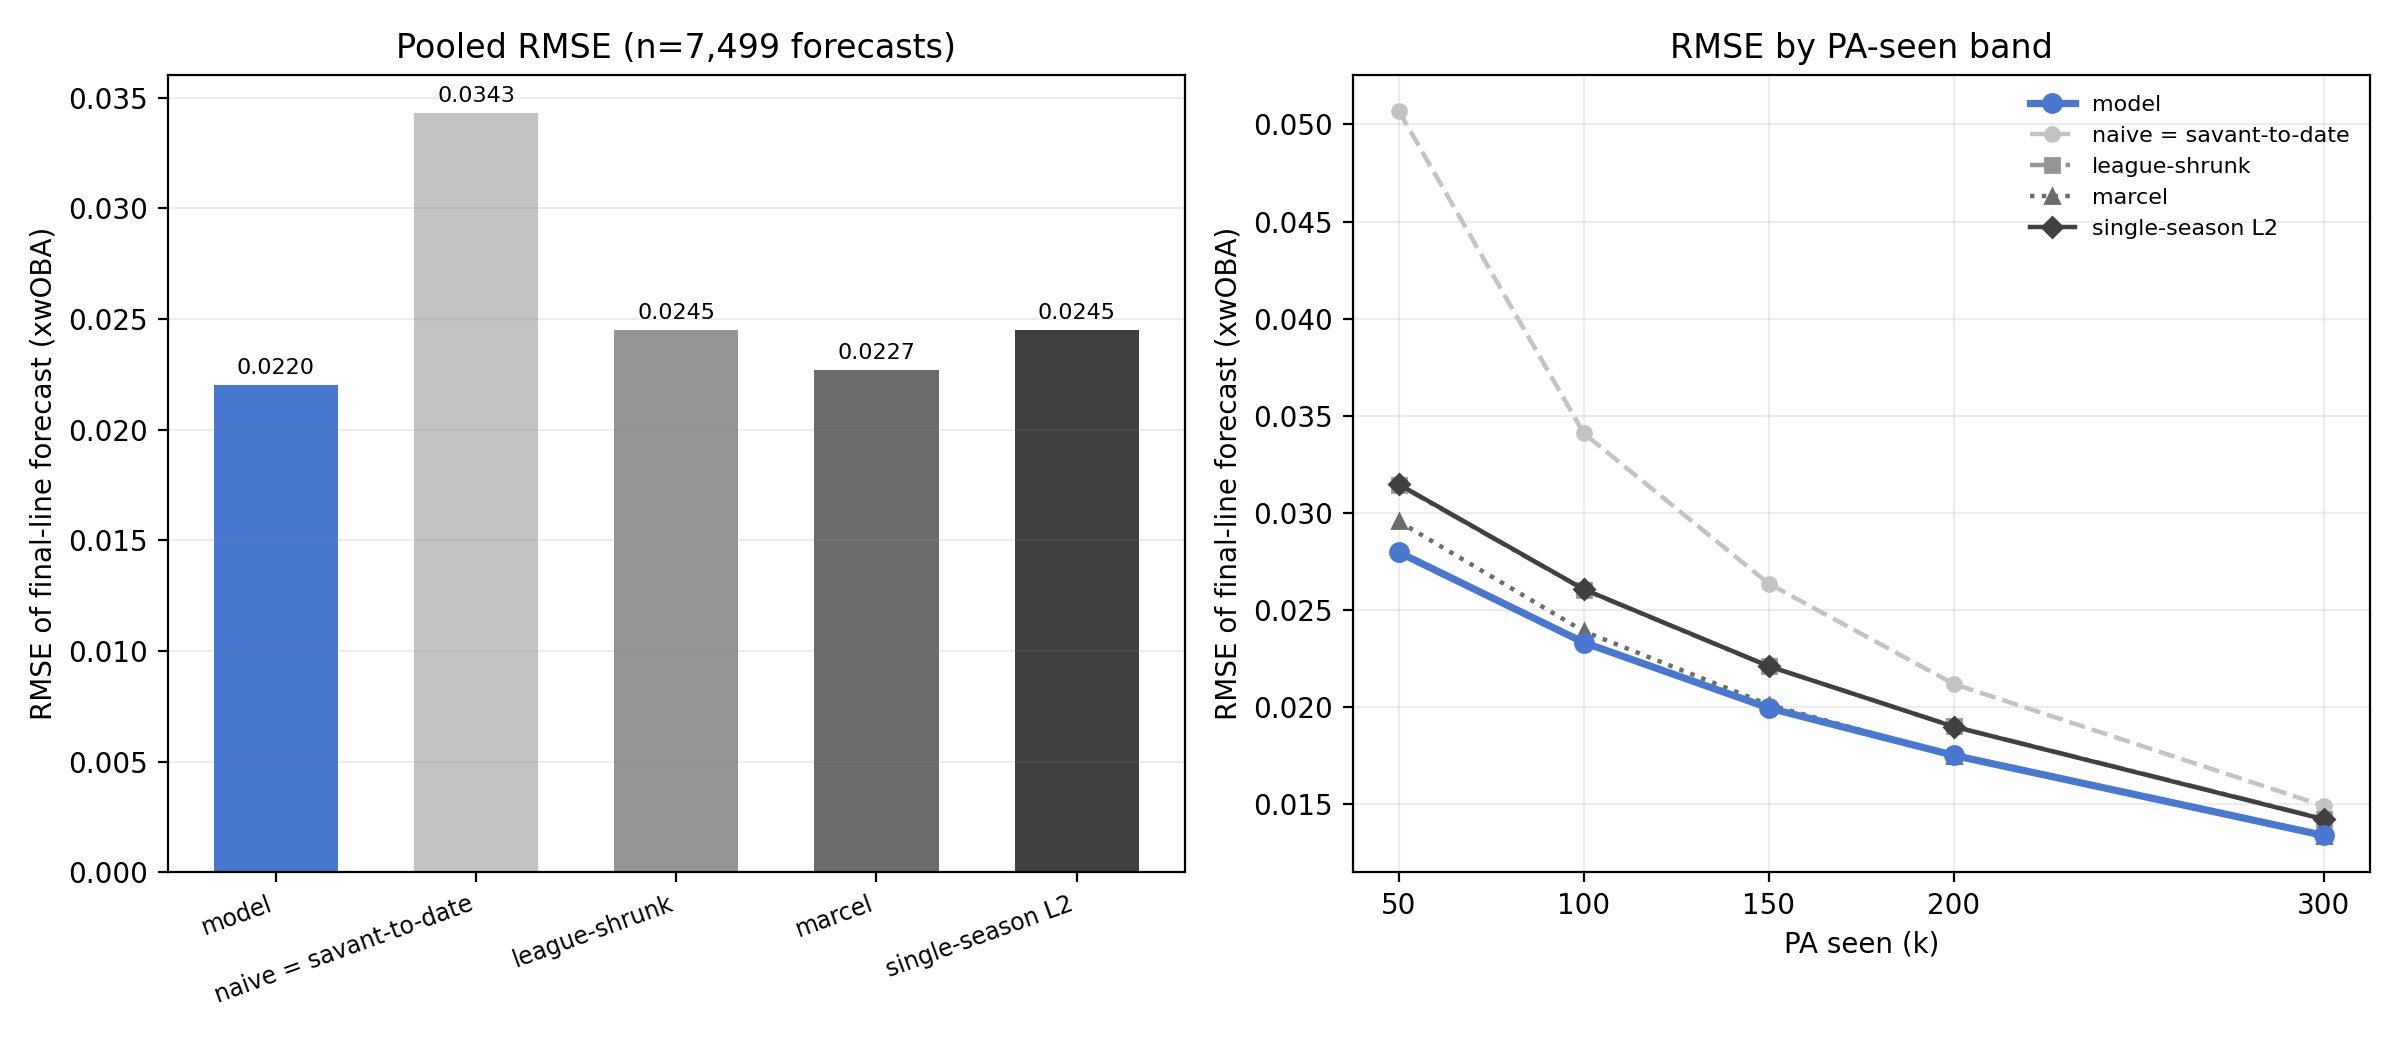

*Final-line forecast RMSE, model vs five benchmarks — pooled (left) and by PAs-seen (right). The model leads throughout; the gap over naive is largest early.*

In [5]:
show_fig("talent3/figures/rmse_vs_benchmarks.png",
         caption="Final-line forecast RMSE, model vs five benchmarks — pooled (left) and by PAs-seen (right). The model leads throughout; the gap over naive is largest early.")

## The gates — three wins, and the one that matters most

I pre-registered five gates. Three are head-to-head bootstrap tests over players, and all three pass:

- **G1 — beats naive at low PA.** With ≤100 PAs seen, Δ **+0.01784** — early in the season, "assume he keeps hitting like this" is badly beaten.
- **G2 — beats single-season Level 2.** Δ **+0.00248**, **CI excludes zero.** This is the headline: history is not free — a hitter's *own past seasons* beat an estimator that sees only the current one.
- **G3 — beats Marcel.** Δ **+0.00069** — a small but real edge over the standard simple projection.

**What to look for:** all three deltas positive with CIs clear of zero, G2 especially.

In [6]:
def boot(key):
    d = pb[key]
    return f"{d['delta']:+.5f}", f"[{d['ci_lo']:+.5f}, {d['ci_hi']:+.5f}]"
rows = []
for key, label, gi in [("G1_model_vs_naive_k<=100", "G1  beats naive (k<=100)", 0),
                       ("G2_model_vs_l2", "G2  beats single-season L2", 1),
                       ("G3_model_vs_marcel", "G3  beats Marcel", 2)]:
    delta, ci = boot(key)
    rows.append({"gate": label, "delta (RMSE)": delta, "95% CI": ci,
                 "verdict": "PASS" if gates[gi]["pass"] else "FAIL"})
pl.DataFrame(rows)

gate,delta (RMSE),95% CI,verdict
"""G1 beats naive (k<=100)""","""+0.01784""","""[+0.01663, +0.01918]""","""PASS"""
"""G2 beats single-season L2""","""+0.00248""","""[+0.00170, +0.00338]""","""PASS"""
"""G3 beats Marcel""","""+0.00069""","""[+0.00017, +0.00120]""","""PASS"""


## The failure I'm not hiding — calibration (G4)

Two gates remain, and one fails. **G5** is the free regression test: strip the career term and evaluate at the full-season cutpoint, and the multi-season machinery has to collapse *exactly* onto Part 2's Phase-1 estimator. It does — to about **5.6e-17** over 2,636 rows — so the new hierarchy is provably not doing something *different* where it should agree.

**G4 is a real, open failure.** The point forecast is good; the *interval* is not honest. The 50% and 80% central intervals run **narrow** — they cover less than they claim — and the 50% gap gets *worse* as more of the season is seen, exactly backwards from "more data should mean better-calibrated uncertainty." At k=300 the nominal 50% interval covers only **0.433**. The 90% band, though, holds within ±5pp everywhere.

**What to look for:** the 0.50 and 0.80 rows below their targets (and the 0.50 row sagging at high *k*), while the 0.90 row stays close to 0.90.

In [7]:
cov = m["coverage_by_k"]
display(pl.DataFrame([
    {"nominal": f"{lv:.0%}", **{f"k={k}": round(cov[str(lv)][str(k)], 3) for k in (50, 100, 150, 200, 300)}}
    for lv in (0.5, 0.8, 0.9)
]))
Markdown(f"**G5 (reduces to Phase 1):** max|theta - xwoba_talent| = **{m['g5']['max_diff']:.2e}** over "
         f"{m['g5']['n']:,} rows — machine zero. **4 of 5 gates pass**; G4 is reported as a real, "
         f"unresolved undercoverage of the central intervals, not tuned away.")

nominal,k=50,k=100,k=150,k=200,k=300
"""50%""",0.495,0.486,0.485,0.479,0.433
"""80%""",0.776,0.768,0.763,0.756,0.766
"""90%""",0.876,0.872,0.869,0.856,0.874


**G5 (reduces to Phase 1):** max|theta - xwoba_talent| = **5.55e-17** over 2,636 rows — machine zero. **4 of 5 gates pass**; G4 is reported as a real, unresolved undercoverage of the central intervals, not tuned away.

**What to look for:** the 50%/80% shades below the diagonal (undercoverage), the 90% shade riding on it — faceted by PAs-seen and by share of season remaining.

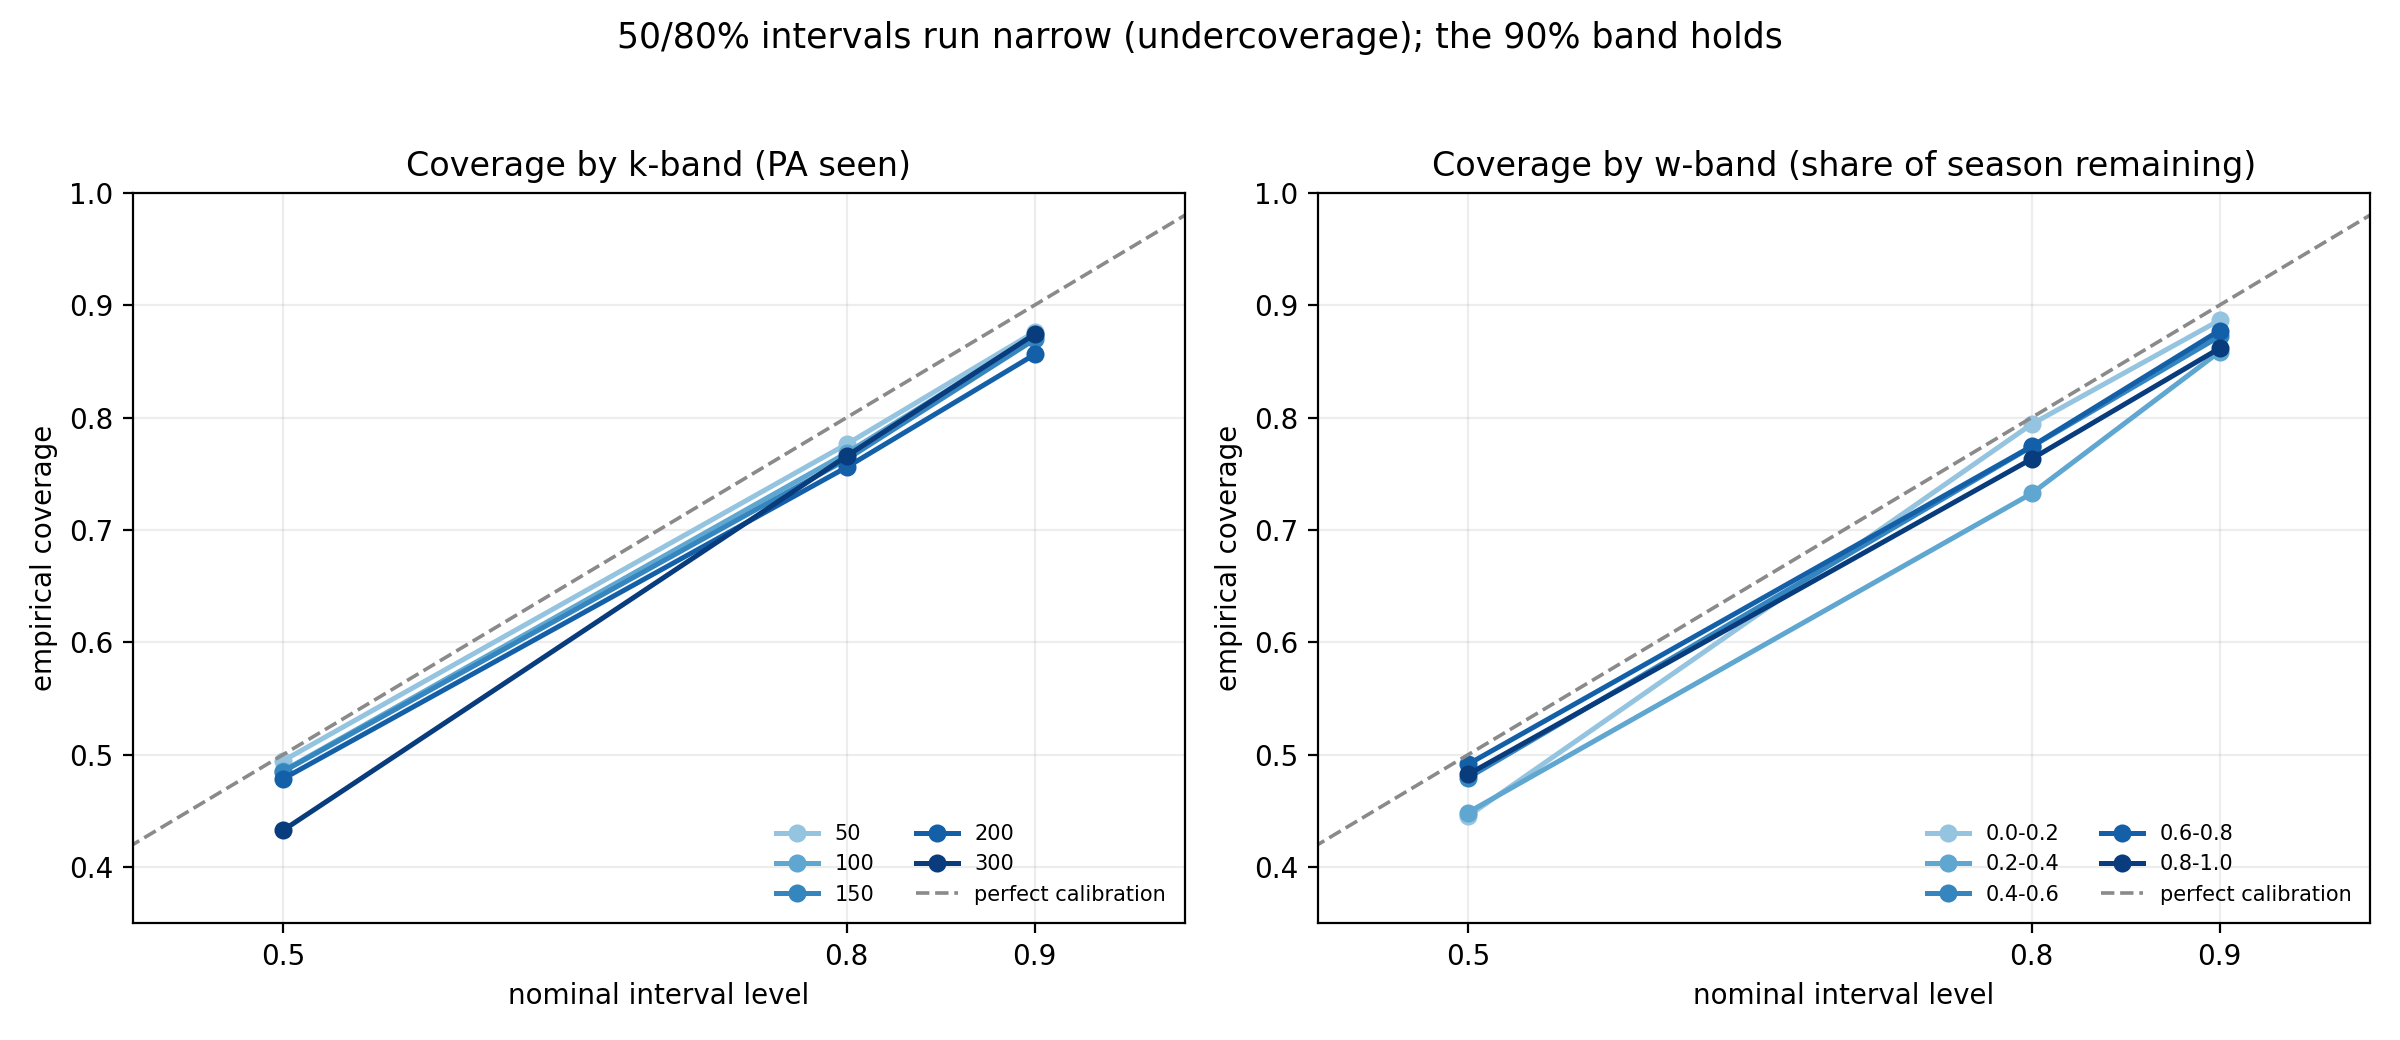

*Empirical vs nominal coverage, by PAs-seen and by season-remaining. 50/80% intervals run narrow; the 90% band holds.*

In [8]:
show_fig("talent3/figures/calibration_by_band.png",
         caption="Empirical vs nominal coverage, by PAs-seen and by season-remaining. 50/80% intervals run narrow; the 90% band holds.")

## The product

Numbers aside, this is what the forecast actually *is* — four hitters' final-line forecast fans across the five cutpoints, each fan narrowing toward the horizontal line at the number they actually finished on. The four were chosen to span the shapes the forecast has to survive: a clear above-average hitter, a near-average one, a hot start that faded, and a cold start that surged.

**What to look for:** the band tightening onto the realized line as *k* grows — and, honestly, Aaron Judge's 2024 panel *missing*, staying conservative under his actual final line even at k=300. His 2024 outran his own 2022–23 history, which a career-intercept model with no aging term structurally can't see coming. That miss is the G4 undercoverage made visible, not hidden by the picture.

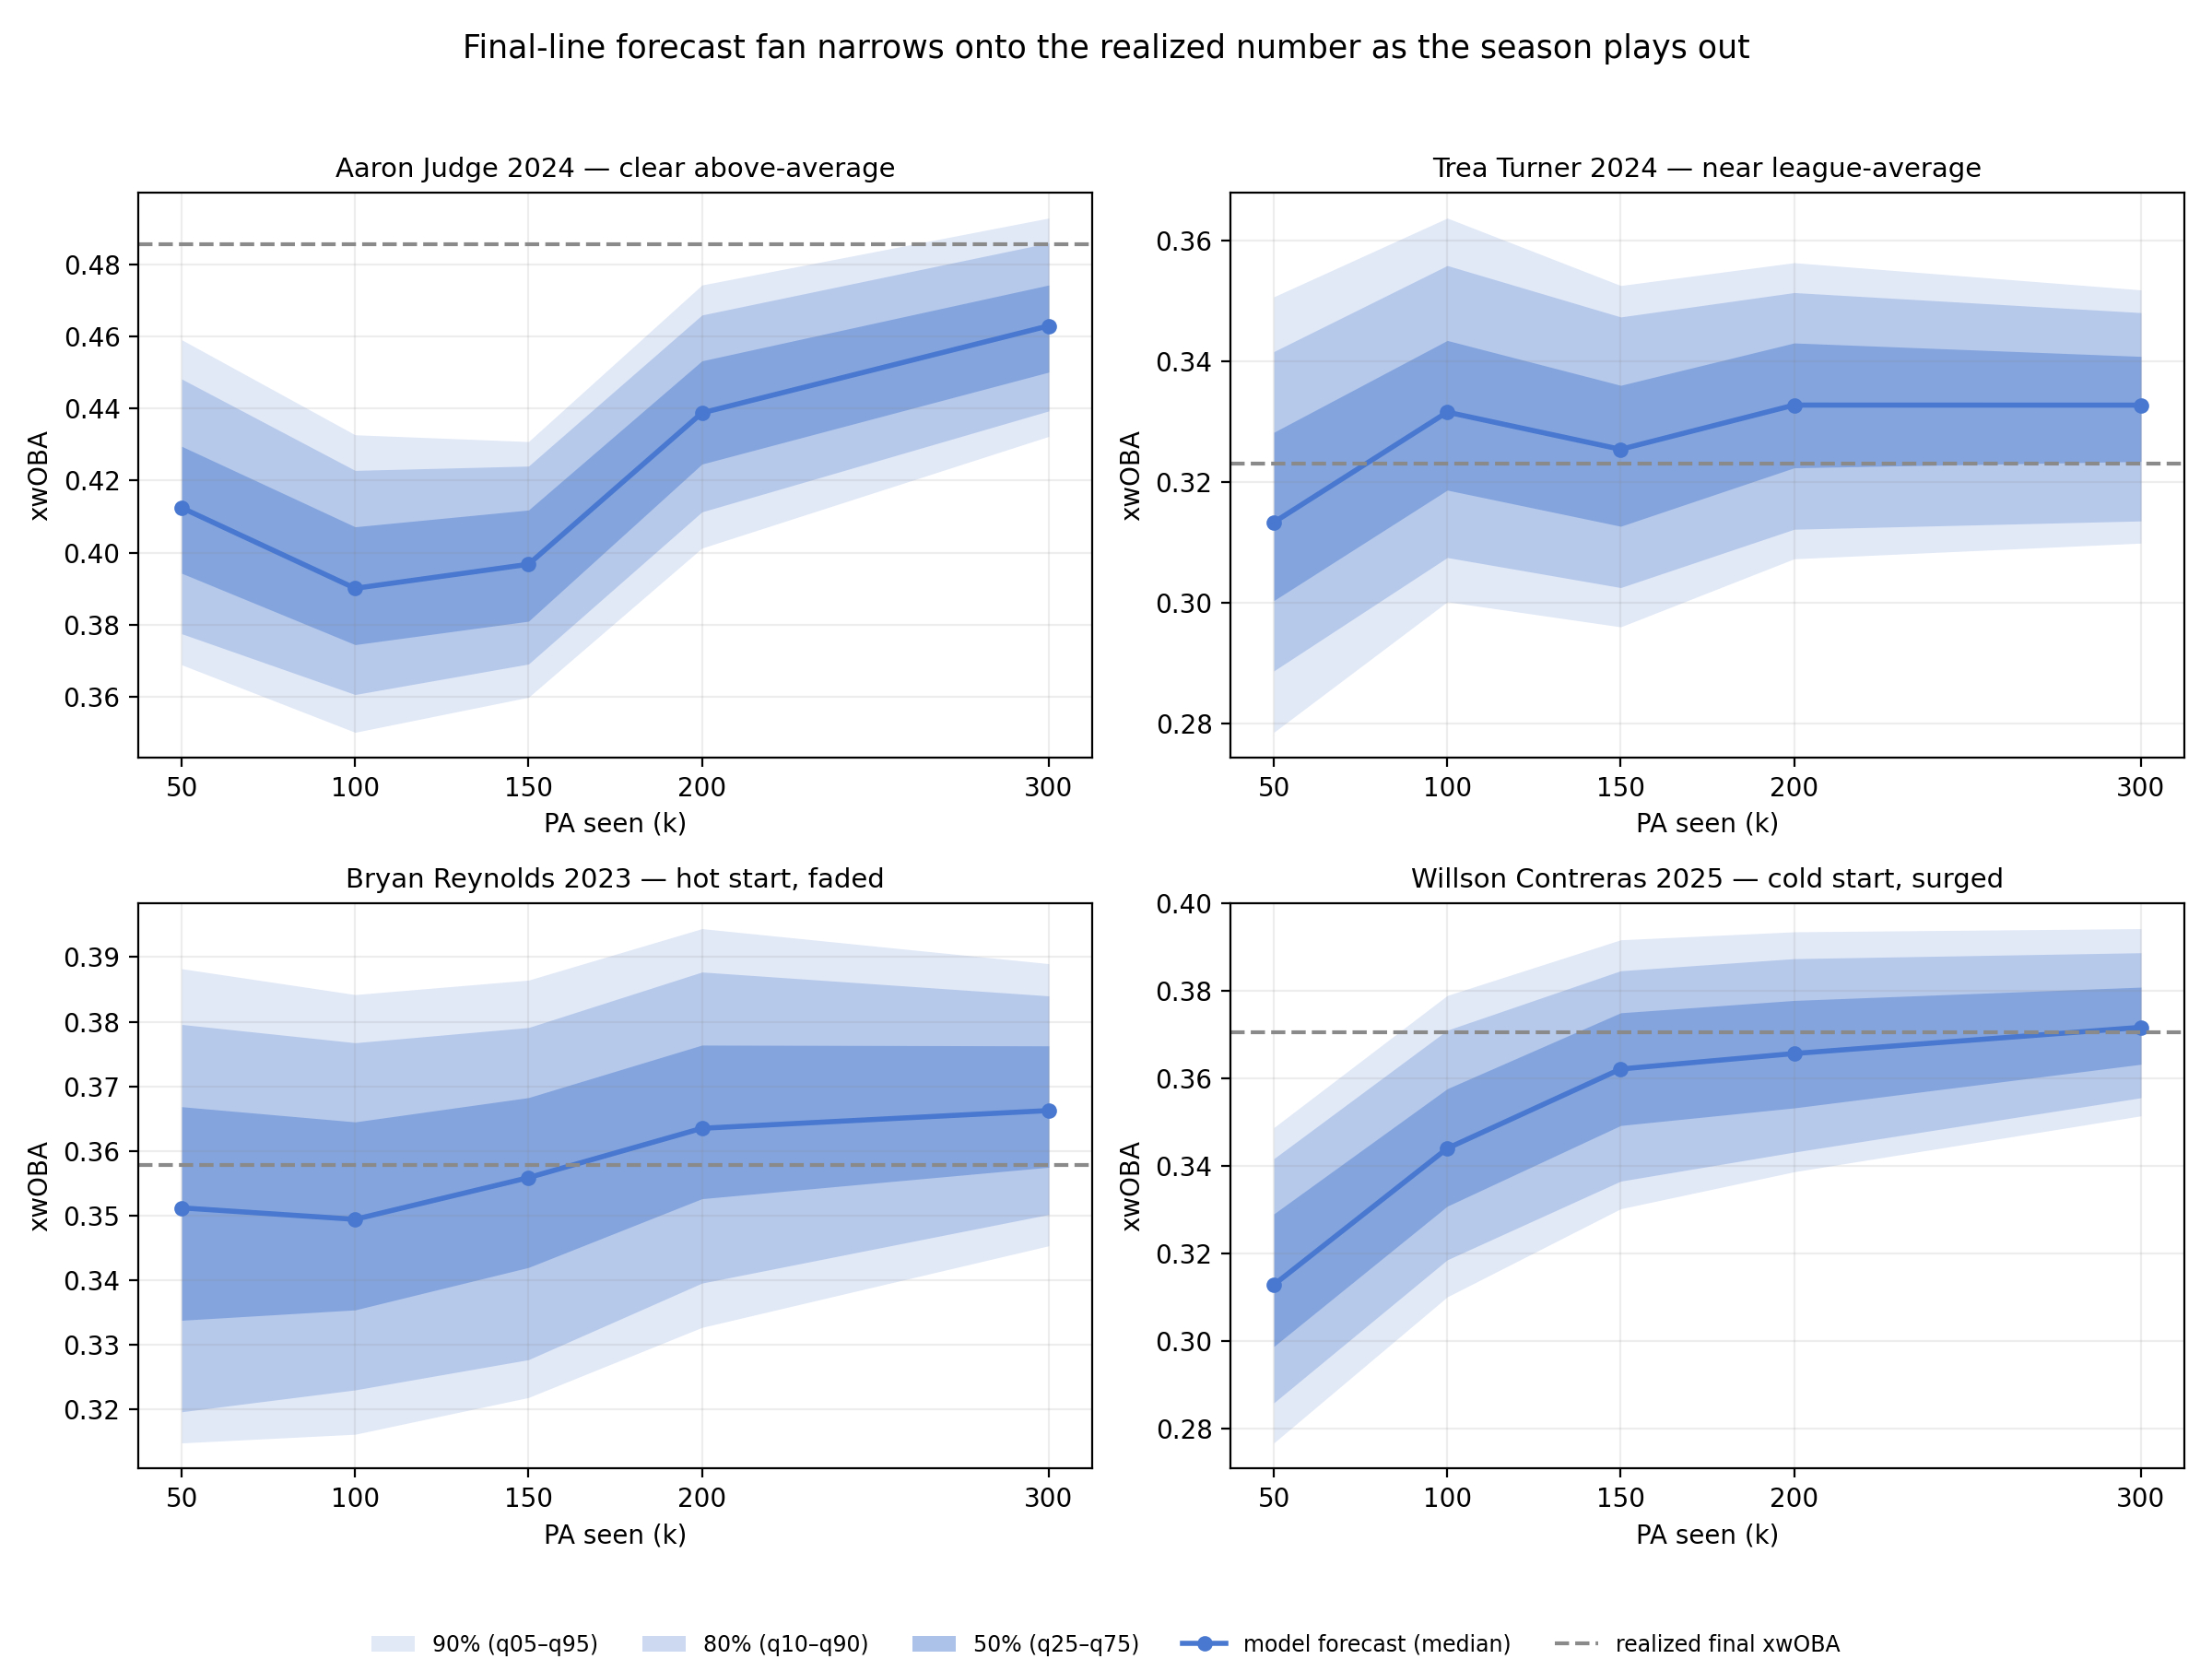

*Final-line forecast fans for four hitters across k = 50-300. Nested 50/80/90% bands narrow toward each player's realized final xwOBA (dashed).*

In [9]:
show_fig("talent3/figures/fan_chart_examples.png",
         caption="Final-line forecast fans for four hitters across k = 50-300. Nested 50/80/90% bands narrow toward each player's realized final xwOBA (dashed).")

## Does spray sharpen the forecast? A well-powered no

Part 1 settled that the 5-feature **spray** surface decisively beats v0 at describing a batted ball — +3,017 nats at matched capacity. The obvious next question for this forecaster: does a hitter's early-season **pull tendency** sharpen the rest-of-season forecast? Spray isn't in Savant's xwOBA, and pull tendency stabilizes fast, so it *could* be exactly the low-PA lever G4's calibration miss is asking for.

Rather than build the full 4-channel measurement model first, I asked the cheap version directly. Per eligible (batter, season, *k*): does early-*k* mean pull add incremental linear signal for the realized rest-of-season xwOBA rate **beyond** early-*k* xwOBA + avg EV + barrel rate? Two OLS fits, incremental R² by cutpoint — seconds, no model. The partial correlation it measures is precisely the talent-covariance borrow the joint-MVN rung would exploit, so a null here is a faithful null for the full rung.

In [10]:
bk = pc["by_k"]
pl.DataFrame([
    {"k": int(k), "n": bk[k]["n"],
     "R2 (xwoba, ev, barrel)": round(bk[k]["r2_base"], 3),
     "+ pull": round(bk[k]["r2_full"], 3),
     "delta R2": round(bk[k]["delta_r2"], 5),
     "pull partial r": round(bk[k]["pull_partial_corr"], 3)}
    for k in ("50", "100", "150", "200", "300")
])

k,n,"R2 (xwoba, ev, barrel)",+ pull,delta R2,pull partial r
50,1945,0.169,0.172,0.00215,-0.051
100,1692,0.224,0.226,0.00207,-0.052
150,1498,0.263,0.263,0.00004,0.008
200,1326,0.285,0.287,0.00128,0.042
300,1032,0.307,0.307,0.00008,0.011


In [11]:
best = max(pc["by_k"].values(), key=lambda d: d["delta_r2"])
Markdown(f"**Verdict: {pc['verdict']}.** Incremental R² tops out at **+{best['delta_r2']:.5f}** "
         f"(k={pc['low_k']}) against a **{pc['go_threshold']}** go bar — ~5x below threshold at its best, and "
         f"below even a 0.005 'irrelevant' line at every cutpoint.")

**Verdict: STOP.** Incremental R² tops out at **+0.00215** (k=50) against a **0.01** go bar — ~5x below threshold at its best, and below even a 0.005 'irrelevant' line at every cutpoint.

This is a **well-powered** null, not an underpowered shrug: at the real k=50 sample (n=1,945) a deliberately injected weak effect of ΔR²≈0.04 clears the bar easily, so a real effect would have shown. It's unchanged with season fixed effects and pull×season interactions (ruling out the 2023 shift-ban or league drift masking it), and `pull` is a genuine, fully-populated, varying feature at every band. Feature assembly is leakage-safe — early features are strictly the first-*k* game-date-sorted PAs, target is the realized remainder.

**Reading: spray improves ball *description* but is forecast-redundant.** A hitter's pull tendency carries almost no information about his future xwOBA once his early exit velocity and barrel rate — the same power skill, stabilizing just as fast — are already in the model. That closes the spray thread that ran through the whole project: it failed at m=50 (a capacity artifact), won decisively at m=200 (description), and adds nothing to the forecast (prediction). A coherent **description-yes / forecast-no**.

## Where this leaves the series — and the project

Three parts, and the shape of it is clear. **Part 1** built a faithful, well-calibrated xwOBA surface that sits at Savant's accuracy ceiling with three features and — even when a decisively better 5-feature surface exists — cannot turn better *description* into better *prediction*. **Part 2** turned that ceiling into a different kind of value: an honest sample-size-aware band, a true-talent estimate that beats Savant at low PA, and a peripheral-informed prior that helps exactly where the sample is thin. **Part 3** changed the object from describing a season to **forecasting** one, and beat Marcel and single-season Level 2 with CIs that exclude zero — while being honest that the intervals run narrow (G4) and that spray, the surface win, buys nothing here.

What's left stacks on top of this rung (a):

1. **Rung (b): peripherals in the measurement.** Feed Level 2's joint read on (xwOBA, exit velo, barrel rate) into the hierarchy — the EV/barrel-only version, *without* spray, which the pre-check above deliberately controlled *for* and so says nothing about.
2. **Rung (c): aging and drift.** A shared aging curve (needs external birthdates) and an AR(1) on the season term — the most likely fix for the Judge-2024 kind of miss.
3. **Honest intervals.** Recalibrate the predictive spread when little season is left, and fold in the Part 2 surface-uncertainty term — the thread that would finally close the G4 gap.

Full write-ups: `results/talent3/NOTES.md` (including §"Rung b — spray peripheral: a documented negative") and `results/RESULTS.md`; the design is in `docs/superpowers/specs/2026-07-20-xwobart-rest-of-season-forecast-design.md`.

In [12]:
# guard: every number quoted in the prose above, checked against the committed artifacts under
# results/talent3/ — fails loudly instead of letting the text silently drift out of date.
# (This asserts the committed re-run metrics.json — n_forecasts 7499; the original run's 7,493-forecast
#  numbers live in RESULTS.md / NOTES.md, see the re-run note in results/talent3/NOTES.md.)

# -- scale + leakage
assert m["leakage"]["n_forecasts"] == 7499 and m["leakage"]["n_conditioning_rows"] == 4678521
assert m["leakage"]["assert_causal"] == "passed"
assert m["n_pairs"] == 1945 and m["n_batters"] == 778
assert m["eligible_counts_by_k"]["50"] == 1945
assert m["eligible_counts_by_k"]["50"] + m["eligible_counts_by_k"]["100"] == 3638   # G1 n(k<=100)

# -- the race
assert round(pr["model"]["rmse"], 5) == 0.02202                                     # "0.0220"
assert round(pr["marcel"]["rmse"], 5) == 0.02271 and round(pr["l2"]["rmse"], 5) == 0.02450
assert round(pr["league"]["rmse"], 5) == 0.02448
assert pr["naive"]["rmse"] == pr["savant"]["rmse"]                                  # identical by construction
assert pr["model"]["rmse"] < min(pr[k]["rmse"] for k in ("marcel", "l2", "league", "naive", "savant"))

# -- the three passing gates
assert round(pb["G1_model_vs_naive_k<=100"]["delta"], 5) == 0.01784
assert round(pb["G2_model_vs_l2"]["delta"], 5) == 0.00248 and pb["G2_model_vs_l2"]["ci_lo"] > 0
assert round(pb["G3_model_vs_marcel"]["delta"], 5) == 0.00069 and pb["G3_model_vs_marcel"]["ci_lo"] > 0

# -- G4 fails, G5 reduces to Phase 1
assert [g["pass"] for g in gates] == [True, True, True, False, True]
assert [g["name"] for g in gates] == ["G1_beats_naive_low_pa", "G2_beats_or_ties_l2",
    "G3_beats_or_ties_marcel", "G4_calibration_5pp", "G5_phase1_reduction"]
assert m["g5"]["max_diff"] < 1e-15 and m["g5"]["n"] == 2636
_cov5 = m["coverage_by_k"]["0.5"]
assert round(_cov5["300"], 3) == 0.433                                              # 50% narrowest at high k
assert min(_cov5.values()) == _cov5["300"]                                          # the 50% gap worst at high k
assert all(m["coverage_by_k"]["0.8"][k] < 0.8 for k in ("50", "100", "150", "200", "300"))  # 80% runs narrow
assert all(abs(m["coverage_by_k"]["0.9"][k] - 0.9) <= 0.05 for k in ("50", "100", "150", "200", "300"))  # 90% holds

# -- rung-b spray pre-check (guarded against precheck_pull.json)
assert pc["verdict"] == "STOP" and pc["low_k"] == 50 and pc["go_threshold"] == 0.01
_bk = pc["by_k"]
assert _bk["50"]["n"] == 1945                                                       # well-powered n
assert round(_bk["50"]["delta_r2"], 5) == 0.00215                                   # tops out at +0.0022 (k=50)
assert max(v["delta_r2"] for v in _bk.values()) == _bk["50"]["delta_r2"]            # k=50 is the max
assert all(v["delta_r2"] < 0.005 for v in _bk.values())                            # below the 0.005 "irrelevant" line everywhere
assert all(v["delta_r2"] < pc["go_threshold"] for v in _bk.values())               # below the go bar everywhere
assert round(_bk["50"]["r2_base"], 3) == 0.169 and round(_bk["50"]["r2_full"], 3) == 0.172

print("prose numbers still match the artifacts")

prose numbers still match the artifacts
